# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [22]:
# !pip install mat73 h5py

In [23]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [24]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    '../data'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : ../data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [25]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [26]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [27]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [28]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [29]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [30]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [31]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [32]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [33]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

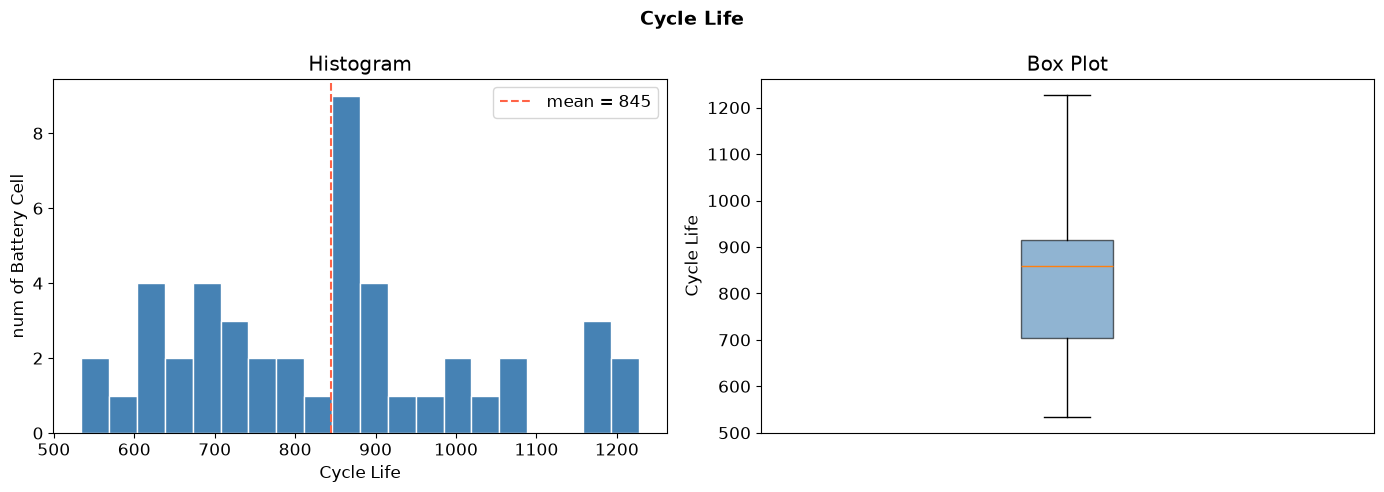

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [34]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

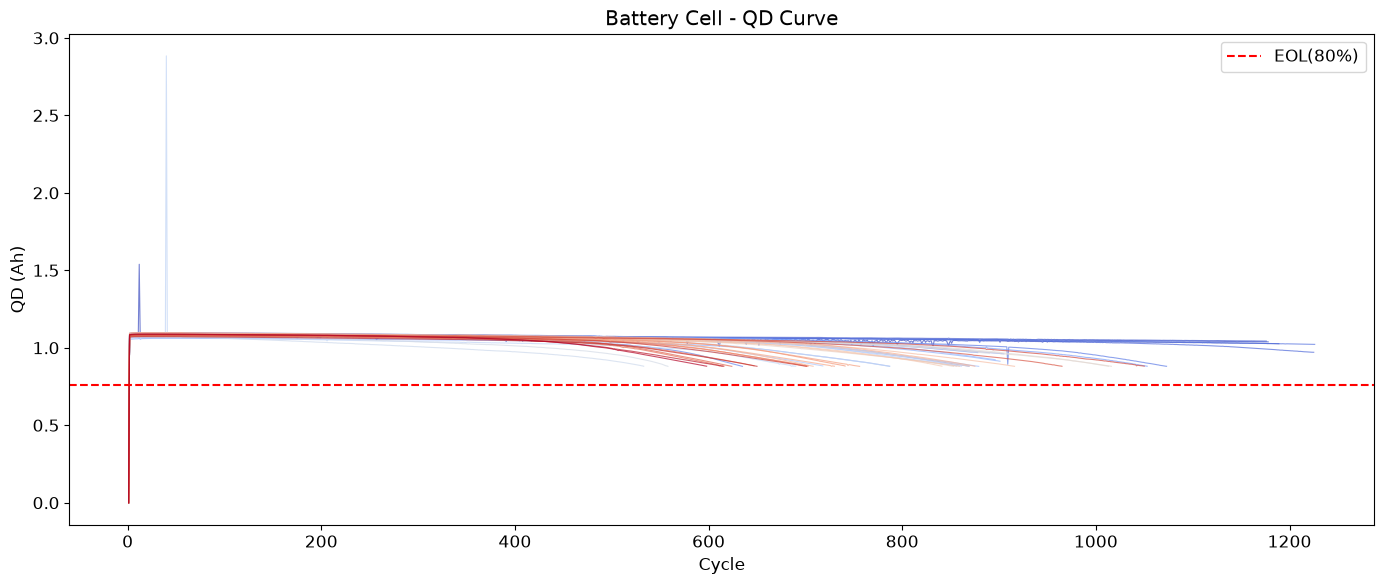

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


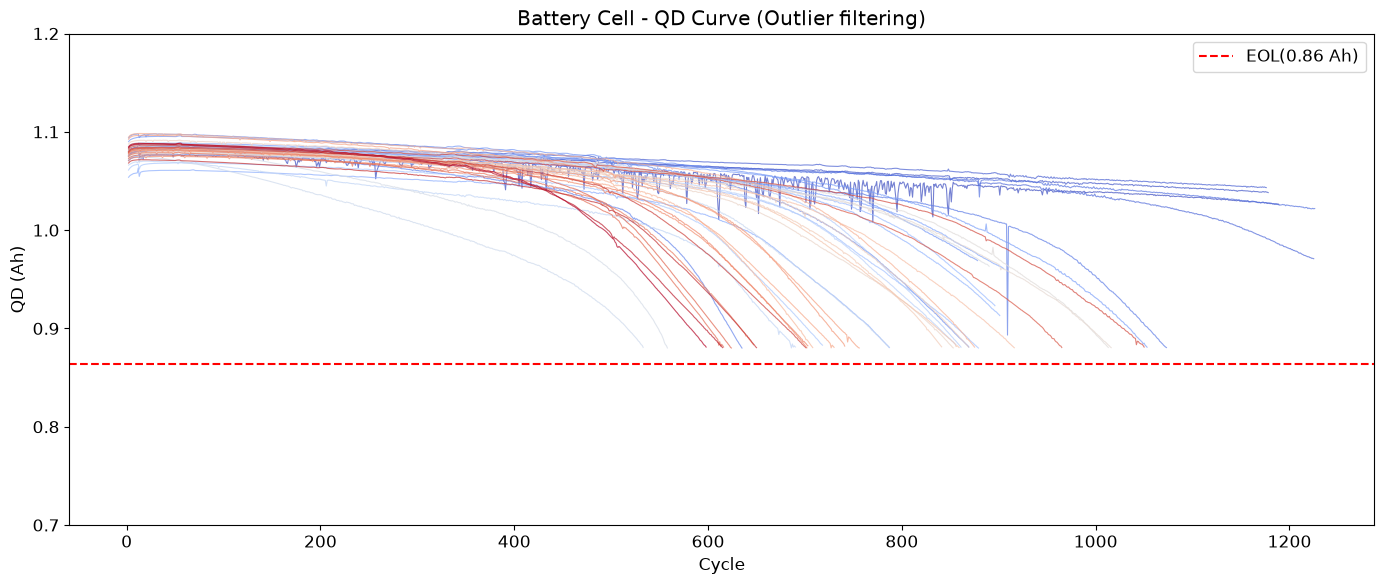

In [36]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

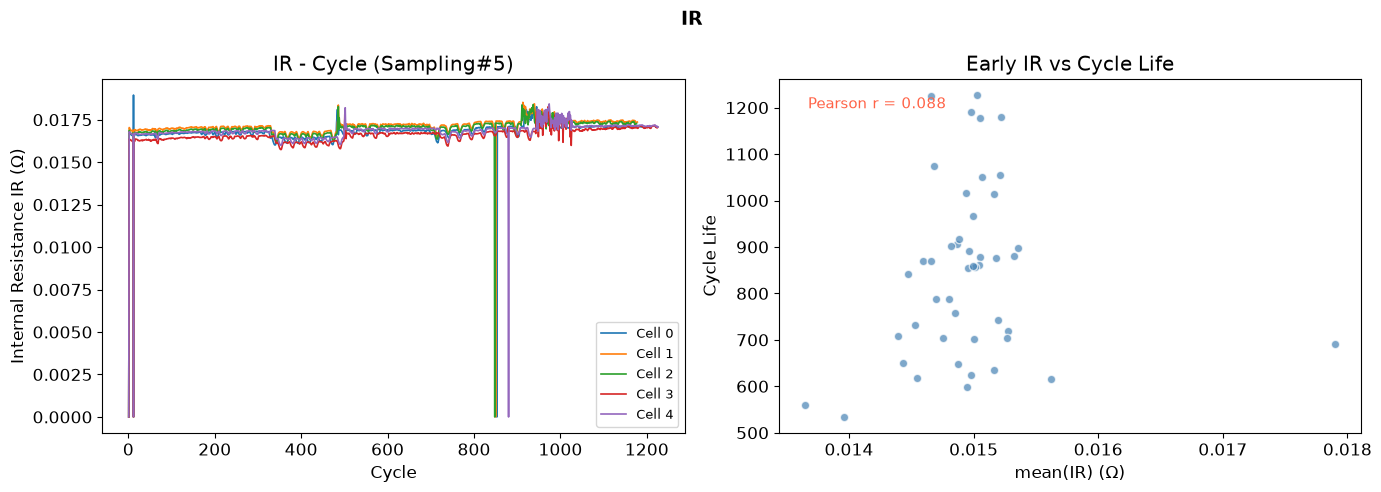

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

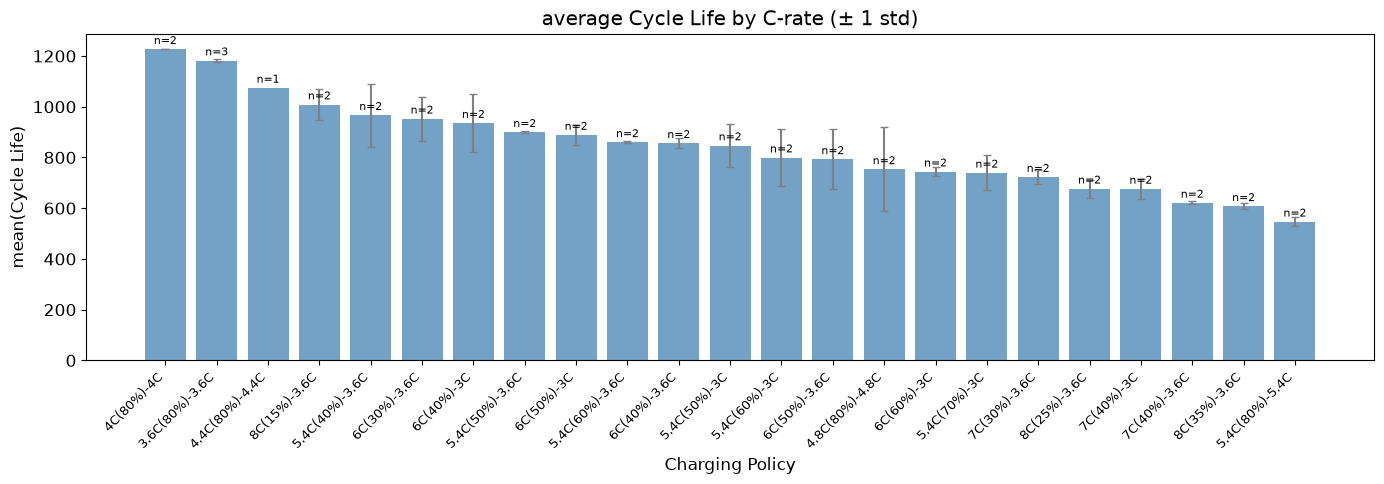

In [38]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

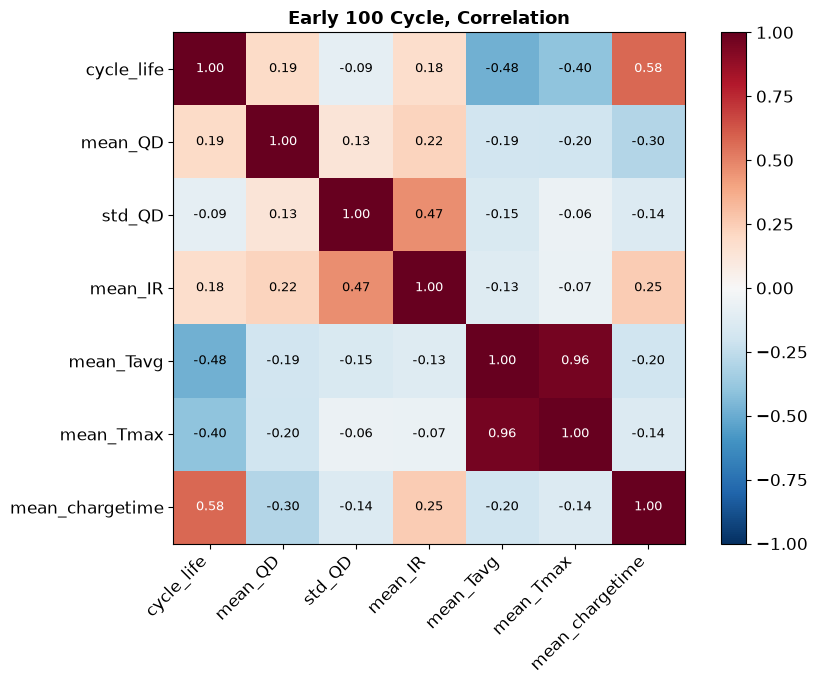


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [39]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

## EDA

In [40]:
import gc, pickle, re
from scipy.stats import skew, kurtosis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

EPS = 1e-12                        # log(0) 오류를 막기 위해 더하는 아주 작은 값
N_EARLY, N_LATE = 10, 100          # ΔQ(V) = Q(사이클100) - Q(사이클10): 초기 변화량 (사이클 1은 값이 0이라 제외)
BATCH_FILES = {                    # Batch 1은 이미 메모리에 있으므로 2, 3만 읽음
    'batch2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'batch3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
COLORS = {'batch1': 'tab:blue', 'batch2': 'tab:orange', 'batch3': 'tab:green'}  # 배치별 색 통일: 그래프에서 배치 비교용

def get_field(cell, key, k):
    # 사이클 k번의 변수(예: Qdlin)를 꺼냄. cycles가 dict-of-list인 mat73 구조 대응.
    # 사이클 번호 범위를 벗어나면 None 반환 → 오류로 멈추지 않고 해당 셀만 제외
    c = cell['cycles']
    try:
        return c[key][k] if isinstance(c, dict) else c[k][key]
    except (IndexError, KeyError):
        return None

def to_arr(x):
    # 리스트/배열을 1차원 실수 배열로 통일 (None은 그대로 None)
    return None if x is None else np.asarray(x, dtype=float).ravel()

def first_crate(policy):
    # "8C(35%)-3.6C" → 8.0 (1단계 충전 속도). Q4(충전 속도와 수명) 분석을 위해 문자열을 숫자로 변환
    m = re.match(r'\s*([\d.]+)C', policy)
    return float(m.group(1)) if m else np.nan

def knee_cycle(qd, frac=0.95):
    # knee(급격한 열화 시작점) 근사: 용량이 초기 중앙값의 95% 아래로 '3사이클 연속' 내려간 첫 사이클
    # 3사이클 연속 조건을 쓰는 이유: 일시적 측정 스파이크를 knee로 오인하지 않기 위해
    qd = np.asarray(qd, float)
    below = qd < frac * np.median(qd[2:12])
    below[:2] = False                                # 사이클 0, 1은 값이 0이라 제외
    for k in range(2, len(qd) - 2):
        if below[k] and below[k + 1] and below[k + 2]:
            return k
    return np.nan                                    # 못 찾으면 결측 (정식 knee 알고리즘이 아닌 근사임을 PDF 한계에 명시)

dq_curves, qd_curves, Vdlin = {}, {}, None           # 곡선을 따로 저장 → 그래프에서 재사용해 2~3GB 파일을 다시 읽지 않음

def extract(cell, bname, i):
    qa, qb = to_arr(get_field(cell, 'Qdlin', N_LATE)), to_arr(get_field(cell, 'Qdlin', N_EARLY))
    if qa is None or qb is None or len(qa) != len(qb):
        return None                                  # 사이클 100이 없는 셀은 제외 (몇 개 빠졌는지 셀 2에서 확인)
    dq = qa - qb                                     # ΔQ(V): 두 사이클 방전 곡선의 차이
    dqf = dq[np.isfinite(dq)]                        # NaN 제거 후 통계 계산
    s = cell['summary']
    qd, ir = np.asarray(s['QDischarge'], float), np.asarray(s['IR'], float)
    tavg, tmax = np.asarray(s['Tavg'], float), np.asarray(s['Tmax'], float)
    ct = np.asarray(s['chargetime'], float)
    if len(dqf) < 10 or len(qd) <= N_LATE:
        return None
    w = slice(2, N_LATE + 1)                         # 초기 구간: 사이클 2~100
    k, qw = np.arange(2, N_LATE + 1), qd[2:N_LATE + 1]
    ok = (qw > 0.5) & (qw < 1.5)                     # 용량 이상값 제외 후 기울기 계산 (초기 스파이크 영향 차단)
    slope = np.polyfit(k[ok], qw[ok], 1)[0] if ok.sum() > 5 else np.nan   # 초기 용량 감소 속도
    cw = ct[w]; cw = cw[(cw > 0) & (cw < 60)]        # 충전시간 측정 오류(최댓값 419 등) 제거
    pol = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
    row = dict(
        batch=bname, cell_id=i, cycle_life=int(cell['cycle_life']), policy=pol, c1=first_crate(pol),
        # ΔQ(V) 모양을 5개 통계로 요약: 샘플(셀 약 40개) 대비 피처 수를 줄이기 위함. log10은 자릿수 차이를 줄여 상관을 보기 쉽게 함
        dq_min=np.log10(abs(dqf.min()) + EPS), dq_var=np.log10(dqf.var() + EPS),
        dq_mean=np.log10(abs(dqf.mean()) + EPS), dq_skew=np.log10(abs(skew(dqf)) + EPS),
        dq_kurt=np.log10(abs(kurtosis(dqf)) + EPS),
        qd_2=qd[2], qd_slope=slope,                  # 초기 용량, 초기 용량 감소 기울기
        ir_2=ir[2], ir_diff=ir[N_LATE] - ir[2],      # 초기 내부저항, 100사이클간 저항 증가량
        tavg_mean=np.nanmean(tavg[w]), tmax_mean=np.nanmean(tmax[w]),   # 온도: 열화 가속 요인
        chargetime_mean=cw.mean() if len(cw) else np.nan,                # 충전시간: C-rate와 직결
        knee=knee_cycle(qd),                         # 열화가 꺾이는 시점
    )
    return row, dq, qd

def process_batch(cells, bname):
    # 한 배치의 모든 셀에 extract를 돌려 표(DataFrame)를 만듦
    global Vdlin
    rows = []
    for i, cell in enumerate(cells):
        out = extract(cell, bname, i)
        if out is None:
            continue
        row, dq, qd = out
        rows.append(row); dq_curves[(bname, i)] = dq; qd_curves[(bname, i)] = qd
        if Vdlin is None and cell.get('Vdlin') is not None:
            Vdlin = np.asarray(cell['Vdlin']).ravel()   # ΔQ 그래프의 x축(전압) 저장
    return pd.DataFrame(rows)

In [41]:
feat1 = process_batch(batch, 'batch1')   # batch는 노트북 위쪽에서 이미 읽어 둔 Batch 1
print("피처 테이블:", feat1.shape, "| 원본 셀 수:", len(batch))   # 두 숫자 차이 = 데이터 부족으로 제외된 셀 수
feat1.head()

피처 테이블: (46, 18) | 원본 셀 수: 46


,batch,cell_id,cycle_life,policy,c1,dq_min,dq_var,dq_mean,dq_skew,dq_kurt,qd_2,qd_slope,ir_2,ir_diff,tavg_mean,tmax_mean,chargetime_mean,knee
0,batch1,0,1190,3.6C(80%)-3.6C,3.6,-2.050261,-5.051526,-2.553712,-0.138643,-0.040960,1.071900,0.000014,0.016724,-0.000074,31.600557,35.373827,13.384245,NaN
1,batch1,1,1179,3.6C(80%)-3.6C,3.6,-2.045150,-5.135776,-2.428027,-0.499000,0.016426,1.076612,0.000001,0.017010,-0.000005,31.325670,34.158157,13.373840,NaN
2,batch1,2,1177,3.6C(80%)-3.6C,3.6,-1.986994,-4.951883,-2.383163,-0.359039,0.069572,1.081315,0.000007,0.016832,0.000027,31.474905,34.542674,13.378886,NaN
3,batch1,3,1226,4C(80%)-4C,4.0,-1.703321,-4.386348,-2.104748,-0.322093,0.050851,1.081228,0.000014,0.016316,0.000098,29.937669,30.658066,12.053272,1037.0
4,batch1,4,1227,4C(80%)-4C,4.0,-1.837397,-4.604779,-2.202790,-0.456945,0.133910,1.079012,0.000016,0.016740,0.000011,31.446247,34.380456,12.054163,1181.0


knee NaN 개수: 3 / 46
   cell_id  cycle_life          policy
0        0        1190  3.6C(80%)-3.6C
1        1        1179  3.6C(80%)-3.6C
2        2        1177  3.6C(80%)-3.6C
초기 중앙값: 1.0741829 | 95% 기준: 1.020473755
후반 값(사이클 1000~1010): [1.039 1.039 1.039 1.039 1.039 1.039 1.038 1.038 1.038 1.039]


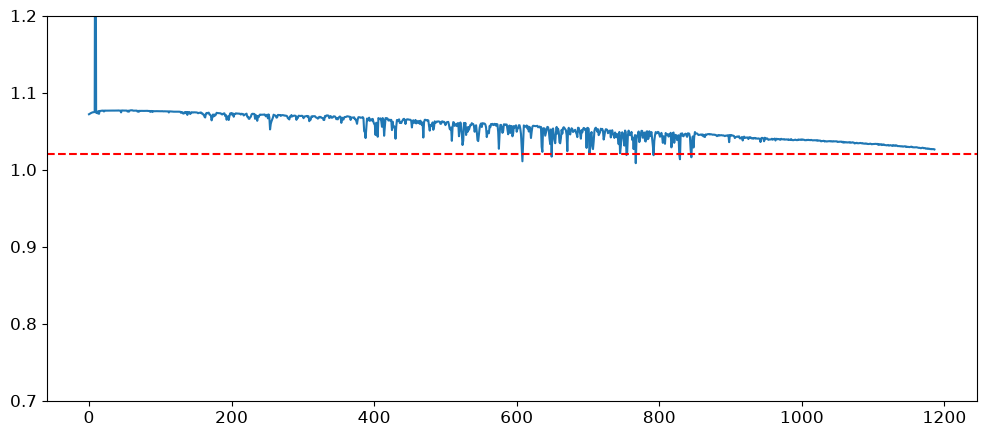

In [42]:
print("knee NaN 개수:", feat1['knee'].isna().sum(), "/", len(feat1))
print(feat1[feat1['knee'].isna()][['cell_id', 'cycle_life', 'policy']])

qd = np.asarray(batch[0]['summary']['QDischarge'], float)
print("초기 중앙값:", np.median(qd[2:12]), "| 95% 기준:", 0.95*np.median(qd[2:12]))
print("후반 값(사이클 1000~1010):", qd[1000:1010].round(3))
plt.plot(qd[2:]); plt.axhline(0.95*np.median(qd[2:12]), color='r', ls='--'); plt.ylim(0.7, 1.2); plt.show()

In [43]:
last_qd = {i: np.asarray(c['summary']['QDischarge'], float)[-1] for i, c in enumerate(batch)}
chk = feat1[['cell_id', 'cycle_life', 'policy']].copy()
chk['last_QD'] = chk['cell_id'].map(last_qd)
chk['last_QD/초기'] = (chk['last_QD'] / feat1['qd_2']).round(3)
print(chk.sort_values('last_QD/초기', ascending=False).head(8))

    cell_id  cycle_life          policy   last_QD  last_QD/초기
2         2        1177  3.6C(80%)-3.6C  1.043279       0.965
1         1        1179  3.6C(80%)-3.6C  1.038225       0.964
0         0        1190  3.6C(80%)-3.6C  1.026210       0.957
4         4        1227      4C(80%)-4C  1.021960       0.947
3         3        1226      4C(80%)-4C  0.970921       0.898
10       10         906    5.4C(50%)-3C  0.961019       0.893
22       22         891    6C(30%)-3.6C  0.963279       0.891
8         8         879  5.4C(40%)-3.6C  0.969025       0.888


In [44]:
chk2 = []
for i, c in enumerate(batch):
    qd = np.asarray(c['summary']['QDischarge'], float)
    L = int(c['cycle_life'])
    idx = np.arange(len(qd))
    below = np.where((qd < 0.88) & (idx >= 50))[0]
    chk2.append(dict(cell_id=i, cycle_life=L, 기록사이클수=len(qd),
                     QD_at_life=round(qd[min(L, len(qd)) - 1], 3),
                     처음_0_88_미만=int(below[0] + 1) if len(below) else None))
chk2 = pd.DataFrame(chk2)
print(chk2.head(12))
print("0.88 미만 도달 셀:", chk2['처음_0_88_미만'].notna().sum(), "/", len(chk2))

    cell_id  cycle_life  기록사이클수  QD_at_life 처음_0_88_미만
0         0        1190    1189       1.026       None
1         1        1179    1178       1.038       None
2         2        1177    1176       1.043       None
3         3        1226    1225       0.971       None
4         4        1227    1226       1.022       None
5         5        1074    1073       0.881       None
6         6         636     635       0.880       None
7         7         870     869       0.881       None
8         8         879     878       0.969       None
9         9        1054    1053       0.881       None
10       10         906     905       0.961       None
11       11         788     787       0.881       None
0.88 미만 도달 셀: 0 / 46


In [46]:
def process_batch(cells, bname):
    global Vdlin
    rows, skipped = [], []
    for i, cell in enumerate(cells):
        cl = np.asarray(cell.get('cycle_life'), dtype=float).ravel()
        if cl.size == 0 or not np.isfinite(cl[0]):       # 정답(수명)이 없는 셀은 제외
            skipped.append(i)
            continue
        out = extract(cell, bname, i)
        if out is None:                                  # 사이클 100이 없는 등 데이터 부족 셀
            skipped.append(i)
            continue
        row, dq, qd = out
        rows.append(row); dq_curves[(bname, i)] = dq; qd_curves[(bname, i)] = qd
        if Vdlin is None and cell.get('Vdlin') is not None:
            Vdlin = np.asarray(cell['Vdlin']).ravel()
    if skipped:
        print(f"[{bname}] 제외된 셀 {len(skipped)}개 (cell_id): {skipped}")
    return pd.DataFrame(rows)

In [47]:
for v in ('m', 'cells'):
    if v in globals():
        del globals()[v]
gc.collect()

219

In [49]:
tables = [feat1]
for bname, fname in BATCH_FILES.items():
    print("loading", bname, "...")                         # 진행 상황 표시 (오래 걸려서)
    m = load_mat(os.path.join(DATA_DIR, fname))
    cells = to_list_of_dicts(m['batch'])
    tables.append(process_batch(cells, bname))
    print(bname, "원본 셀 수:", len(cells))
    del m, cells; gc.collect()                             # 2~3GB 파일을 바로 메모리에서 비움 → 노트북이 죽는 것을 방지

feat = pd.concat(tables, ignore_index=True)                # 3개 배치를 위아래로 합침
feat['log_life'] = np.log10(feat['cycle_life'])            # 수명은 오른쪽으로 치우친 분포라 log를 씌워 상관을 안정적으로 봄
feat.to_csv("../data/features_all.csv", index=False)       # 커널이 죽어도 이 CSV로 복구 + 내일 파이프라인에서 재사용
pickle.dump((dq_curves, qd_curves, Vdlin), open("../data/curves.pkl", "wb"))   # 곡선도 저장
print(feat.groupby('batch').size())

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

loading batch2 ...
로드 완료 (MATLAB v7.3 / HDF5 형식)
[batch2] 제외된 셀 8개 (cell_id): [22, 23, 35, 36, 37, 38, 39, 40]
batch2 원본 셀 수: 47


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

loading batch3 ...
로드 완료 (MATLAB v7.3 / HDF5 형식)
[batch3] 제외된 셀 2개 (cell_id): [23, 32]
batch3 원본 셀 수: 46
batch
batch1    46
batch2    39
batch3    44
dtype: int64


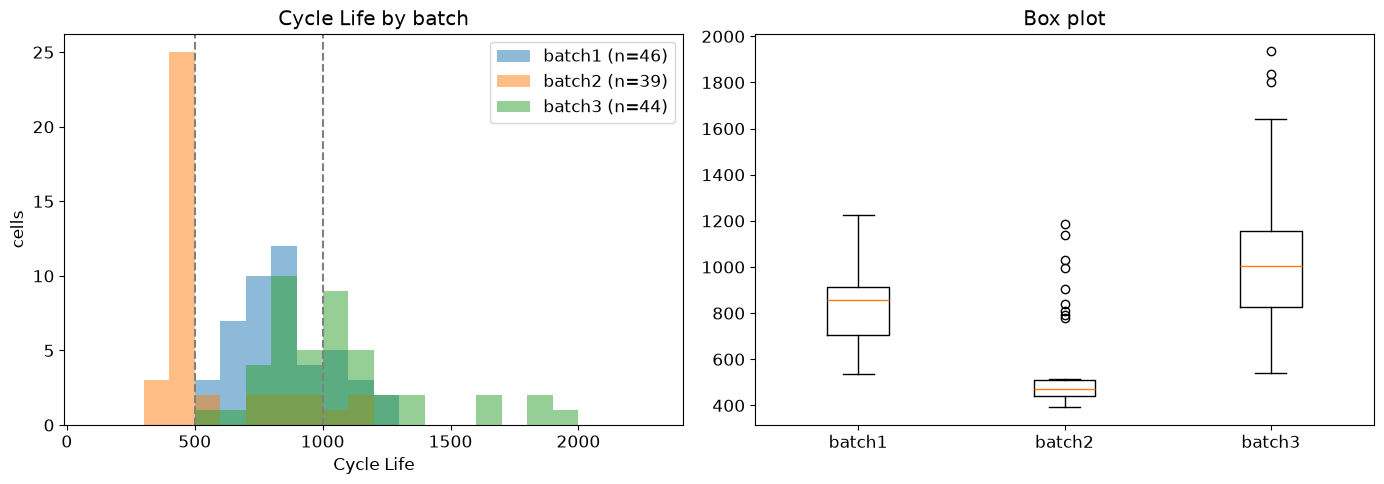

,count,mean,median,std,min,max,skew
batch,,,,,,,
batch1,46,844.72,858.5,184.63,534,1227,0.44
batch2,39,565.74,472.0,222.20,392,1186,1.57
batch3,44,1059.66,1005.5,313.87,541,1935,1.21


life_group,단수명(<500),중간(500~1000),장수명(>1000)
batch,,,
batch1,0.00,0.78,0.22
batch2,0.72,0.21,0.08
batch3,0.00,0.48,0.52



[batch1] 이상치 0개


,cell_id,cycle_life,policy,c1,tavg_mean



[batch2] 이상치 9개


,cell_id,cycle_life,policy,c1,tavg_mean
53,7,777,4.8C(80%)-4.8C-newstructure,4.8,33.766167
54,8,904,5.2C(58%)-4C-newstructure,5.2,33.595768
55,9,791,5.6C(26%)-4.5C-newstructure,5.6,32.352246
76,32,809,4.8C(80%)-4.8C-newstructure,4.8,32.169219
77,33,1140,5.2C(58%)-4C-newstructure,5.2,32.743593
78,34,1186,5.6C(26%)-4.5C-newstructure,5.6,35.668156
81,43,1029,4.8C(80%)-4.8C-newstructure,4.8,33.936234
82,44,841,5.2C(58%)-4C-newstructure,5.2,33.961210
83,45,997,5.6C(26%)-4.5C-newstructure,5.6,35.266021



[batch3] 이상치 3개


,cell_id,cycle_life,policy,c1,tavg_mean
92,7,1836,4.8C(80%)-4.8C-newstructure,4.8,32.797430
121,38,1935,5C(67%)-4C-newstructure,5.0,34.748769
128,45,1801,4.8C(80%)-4.8C-newstructure,4.8,32.726541


In [50]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
bins = np.arange(100, 2400, 100)                           # 과제 범위(150~2,300)를 덮는 구간
for b, g in feat.groupby('batch'):
    ax[0].hist(g['cycle_life'], bins=bins, alpha=0.5, color=COLORS[b], label=f"{b} (n={len(g)})")   # 겹쳐 그려 배치 비교
ax[0].axvline(500, ls='--', c='gray'); ax[0].axvline(1000, ls='--', c='gray')    # 과제 기준선: 단수명<500, 장수명>1000
ax[0].set_xlabel('Cycle Life'); ax[0].set_ylabel('cells'); ax[0].legend(); ax[0].set_title('Cycle Life by batch')
names = list(feat.groupby('batch').groups)
ax[1].boxplot([feat[feat.batch == b]['cycle_life'] for b in names])              # 중앙값, 퍼짐, 이상치를 한눈에
ax[1].set_xticks(range(1, len(names) + 1)); ax[1].set_xticklabels(names); ax[1].set_title('Box plot')
plt.tight_layout(); plt.show()

stat = feat.groupby('batch')['cycle_life'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
stat['skew'] = pd.Series({b: skew(g['cycle_life']) for b, g in feat.groupby('batch')})   # 왜도 > 0이면 오른쪽 꼬리 → log 변환 근거
display(stat.round(2))

feat['life_group'] = pd.cut(feat['cycle_life'], [0, 500, 1001, 1e9], right=False,
                            labels=['단수명(<500)', '중간(500~1000)', '장수명(>1000)'])
display(pd.crosstab(feat['batch'], feat['life_group'], normalize='index').round(2))   # 과제가 요구한 장·단수명 비율

for b, g in feat.groupby('batch'):
    q1, q3 = g['cycle_life'].quantile([.25, .75]); iqr = q3 - q1
    out = g[(g.cycle_life < q1 - 1.5 * iqr) | (g.cycle_life > q3 + 1.5 * iqr)]       # IQR 규칙으로 이상치 셀 식별
    print(f"\n[{b}] 이상치 {len(out)}개")
    display(out[['cell_id', 'cycle_life', 'policy', 'c1', 'tavg_mean']])              # '왜 짧은가'의 단서: 충전 정책, 온도

PDF에 쓸 해석 (Q1)

[발견] 수명 분포가 배치마다 달라요. 평균은 Batch 1이 845, Batch 2가 566, Batch 3가 1060이에요. 단수명(<500) 비율은 각각 0% / 72% / 0%이고, 장수명(>1000) 비율은 22% / 8% / 52%예요. IQR 이상치는 Batch 2에서 9개, Batch 3에서 3개이고 모두 newstructure 정책이에요.

[시사점] Batch 1로 학습한 모델은 Batch 2의 대부분 셀(수명 392~510)을 학습 범위(534~) 밖에서 예측해야 해요. 큰 배치 간 분포 이동이 있고, 분포가 오른쪽으로 치우쳐 있어요.

[전략] ① Regression으로 하고(550 분류는 Batch 1이 거의 한 클래스), ② 타깃은 log10(cycle_life)로 변환하며, ③ 범위 밖 예측이 가능한 규제 선형 모델을 베이스라인으로 두고 트리 계열은 비교용으로 쓰며, ④ 성능은 배치별로 따로 보고해요.

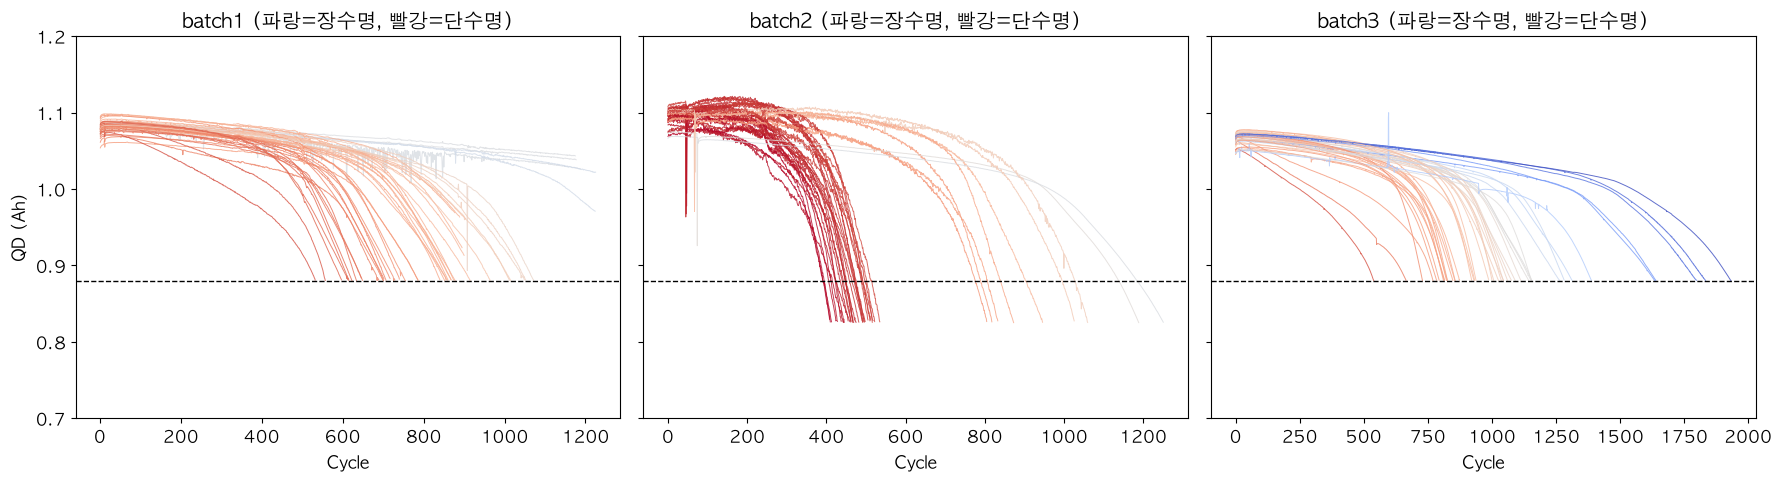

Knee 시점 / 수명 비율:


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
batch1,43.0,0.77,0.07,0.47,0.75,0.77,0.80,0.96
batch2,39.0,0.76,0.06,0.55,0.73,0.76,0.80,0.85
batch3,44.0,0.76,0.09,0.39,0.76,0.78,0.81,0.85


Knee vs cycle_life 상관: {'batch1': np.float64(0.959), 'batch2': np.float64(0.986), 'batch3': np.float64(0.955)}


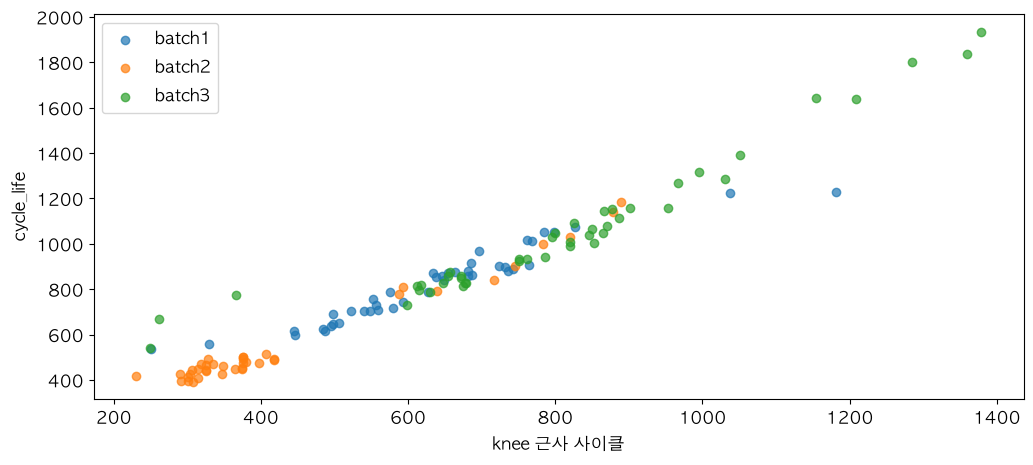

In [53]:
norm = plt.Normalize(feat.cycle_life.min(), feat.cycle_life.max())   # 수명 값을 0~1로 바꿔 색에 대응 (셀 6에서도 재사용)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)         # sharey: 3개 배치를 같은 축으로 비교
for ax, (b, g) in zip(axes, feat.groupby('batch')):
    for _, r in g.iterrows():
        qd = qd_curves[(b, int(r['cell_id']))]
        x = np.arange(len(qd)); ok = (qd > 0.7) & (qd < 1.3)         # 앞쪽 스파이크(측정 오류) 제외
        ax.plot(x[ok], qd[ok], color=cm.coolwarm_r(norm(r['cycle_life'])), lw=0.7, alpha=0.8)
    ax.axhline(0.88, color='k', ls='--', lw=1)                       # EOL: 공칭 약 1.1Ah의 80% = 약 0.88Ah
    ax.set_title(f"{b} (파랑=장수명, 빨강=단수명)"); ax.set_xlabel('Cycle'); ax.set_ylim(0.7, 1.2)
axes[0].set_ylabel('QD (Ah)')
plt.tight_layout(); plt.show()

feat['knee_ratio'] = feat['knee'] / feat['cycle_life']               # knee가 수명의 몇 % 지점인지: 열화 가속 시점 해석
print("Knee 시점 / 수명 비율:"); display(feat.groupby('batch')['knee_ratio'].describe().round(2))
print("Knee vs cycle_life 상관:", {b: round(g['knee'].corr(g['cycle_life']), 3) for b, g in feat.groupby('batch')})
for b, g in feat.groupby('batch'):
    plt.scatter(g['knee'], g['cycle_life'], color=COLORS[b], label=b, alpha=0.7)
plt.xlabel('knee 근사 사이클'); plt.ylabel('cycle_life'); plt.legend(); plt.show()

In [52]:
plt.rcParams['font.family'] = 'AppleGothic'     # Mac 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

[발견] 열화는 초반 완만 → knee 이후 급락으로 가속돼요. knee는 세 배치 모두 수명의 약 76~77% 지점에서 나타나고(상관 0.96~0.99), 초기 용량은 배치마다 달라요(약 1.07 / 1.10 / 1.07~1.08). Batch 2 단수명 셀의 급락이 가장 가팔라요.

[시사점] 초기 100사이클의 QD만으로는 셀을 구분하기 어렵고, knee는 후반에만 관측되므로 예측 피처로 쓸 수 없어요. 용량 절대값은 배치 효과를 학습할 위험이 있어요.

[전략] ① ΔQ(V)처럼 두 사이클의 차이를 이용한 피처를 중심으로 하고, ② knee와 총 사이클 수는 피처에서 제외해 누수를 막고, ③ 절대 용량 피처는 배치 간 일반화를 확인한 뒤 쓸지 정해요.

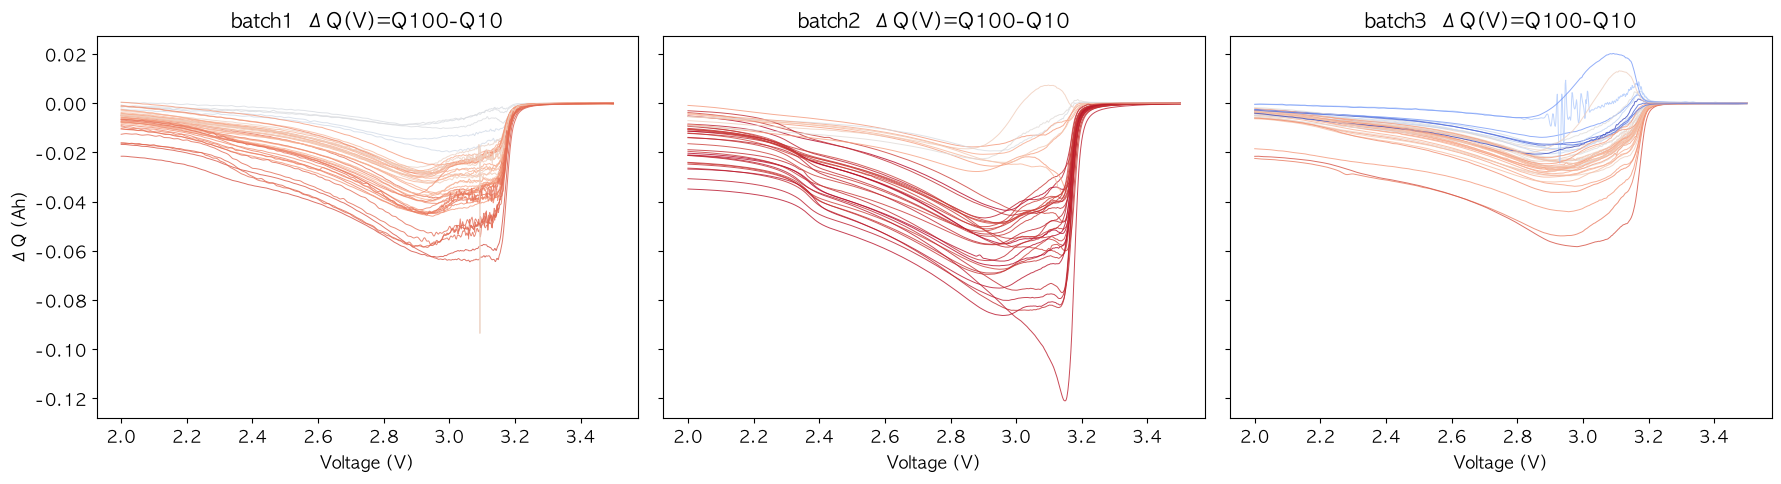

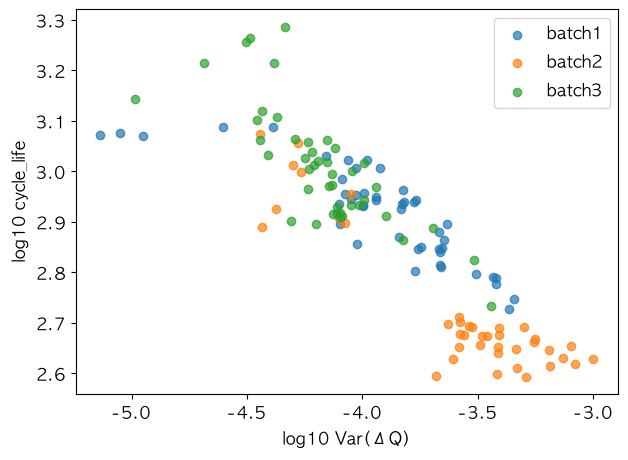

ΔQ 피처 vs log(cycle_life) 상관 (배치별)


,batch1,batch2,batch3
dq_var,-0.846,-0.905,-0.787
dq_min,-0.740,-0.864,-0.766
dq_mean,-0.829,-0.873,-0.668
dq_skew,0.374,0.210,0.031
dq_kurt,0.043,-0.540,0.212


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (b, g) in zip(axes, feat.groupby('batch')):
    for _, r in g.iterrows():
        dq = dq_curves[(b, int(r['cell_id']))]
        x = Vdlin if Vdlin is not None and len(Vdlin) == len(dq) else np.arange(len(dq))   # x축=전압, 길이 안 맞으면 인덱스로 대체
        ax.plot(x, dq, color=cm.coolwarm_r(norm(r['cycle_life'])), lw=0.7, alpha=0.8)      # 색=수명 → 색에 따라 모양이 갈리면 예측 가능
    ax.set_title(f"{b}  ΔQ(V)=Q100-Q10"); ax.set_xlabel('Voltage (V)')
axes[0].set_ylabel('ΔQ (Ah)')
plt.tight_layout(); plt.show()

DQ = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt']
fig, ax = plt.subplots(figsize=(7, 5))
for b, g in feat.groupby('batch'):
    ax.scatter(g['dq_var'], g['log_life'], color=COLORS[b], label=b, alpha=0.7)    # 분산 vs 수명: 관계의 방향·강도를 시각 확인
ax.set_xlabel('log10 Var(ΔQ)'); ax.set_ylabel('log10 cycle_life'); ax.legend(); plt.show()

corr_dq = pd.DataFrame({b: g[DQ].corrwith(g['log_life']) for b, g in feat.groupby('batch')}).round(3)
print("ΔQ 피처 vs log(cycle_life) 상관 (배치별)"); display(corr_dq)   # 그래프의 인상을 숫자로 검증. 배치 간 값이 다르면 일반화 위험

[발견] 사이클 100과 10의 방전 곡선 차이(ΔQ)는 단수명 셀에서 깊고(최대 −0.12Ah) 장수명 셀에서 얕아요. 요약 통계 중 dq_var는 로그 수명과 −0.85 / −0.91 / −0.79(Batch 1/2/3)로 일관되게 강한 음의 상관을 보이고, dq_min, dq_mean도 −0.67~−0.87이에요. dq_skew와 dq_kurt는 약하거나 배치마다 부호가 달라요.

[시사점] 초기 100사이클 안에서 수명 정보를 담은 신호가 있어요. 세 배치가 같은 선형 관계를 따르므로 배치 간 일반화가 가능해 보이지만, Batch 2의 값 범위가 Batch 1 밖이라 범위 밖 예측 능력이 중요해요.

[전략] ΔQ 통계 중 dq_var를 핵심으로, dq_min·dq_mean을 보조로 선택하고, dq_skew·dq_kurt는 제외하거나 후순위로 둬요. 상관이 로그-로그에서 선형이라서 log10(cycle_life) 타깃의 Elastic Net/선형 회귀를 베이스라인으로 삼아요.

,batch,policy,mean,count
10,batch1,5.4C(80%)-5.4C,546.0,2
22,batch1,8C(35%)-3.6C,608.0,2
18,batch1,7C(40%)-3.6C,621.0,2
19,batch1,7C(40%)-3C,676.0,2
21,batch1,8C(25%)-3.6C,676.0,2
17,batch1,7C(30%)-3.6C,722.0,2
9,batch1,5.4C(70%)-3C,740.0,2
16,batch1,6C(60%)-3C,744.0,2
2,batch1,4.8C(80%)-4.8C,753.0,2
14,batch1,6C(50%)-3.6C,792.0,2


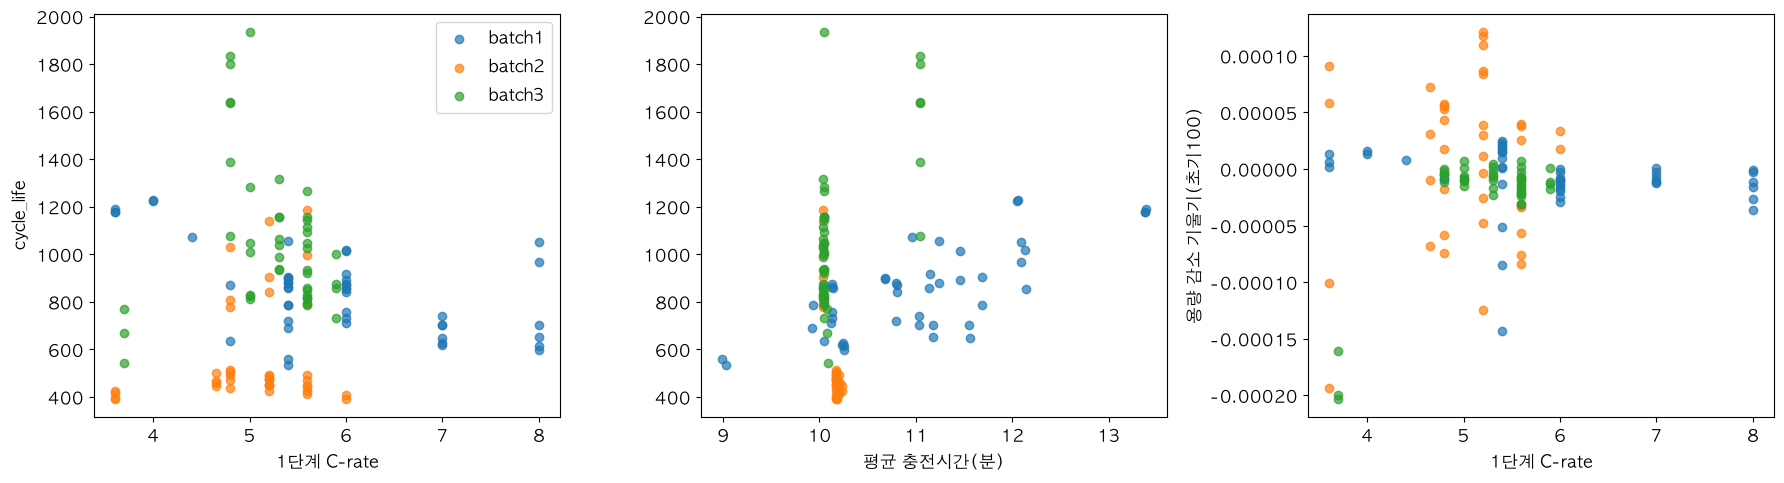

충전 관련 변수 vs log(cycle_life) 상관 (배치별)


,batch1,batch2,batch3
c1,-0.552,0.196,0.018
chargetime_mean,0.727,-0.934,0.594
tavg_mean,-0.439,0.394,-0.015
qd_slope,0.587,-0.424,0.438


In [56]:
pol = feat.groupby(['batch', 'policy'])['cycle_life'].agg(['mean', 'count']).reset_index().sort_values(['batch', 'mean'])
display(pol.round(0))                                        # 정책별 평균 수명. count가 1~2개뿐이므로 '경향성'으로만 해석

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for b, g in feat.groupby('batch'):
    ax[0].scatter(g['c1'], g['cycle_life'], color=COLORS[b], label=b, alpha=0.7)             # 충전 속도 vs 수명
    ax[1].scatter(g['chargetime_mean'], g['cycle_life'], color=COLORS[b], alpha=0.7)         # 충전시간 vs 수명 (느릴수록 오래?)
    ax[2].scatter(g['c1'], g['qd_slope'], color=COLORS[b], alpha=0.7)                        # 충전 속도 vs 열화 속도
ax[0].set_xlabel('1단계 C-rate'); ax[0].set_ylabel('cycle_life'); ax[0].legend()
ax[1].set_xlabel('평균 충전시간(분)'); ax[2].set_xlabel('1단계 C-rate'); ax[2].set_ylabel('용량 감소 기울기(초기100)')
plt.tight_layout(); plt.show()

C4 = ['c1', 'chargetime_mean', 'tavg_mean', 'qd_slope']
print("충전 관련 변수 vs log(cycle_life) 상관 (배치별)")
display(pd.DataFrame({b: g[C4].corrwith(g['log_life']) for b, g in feat.groupby('batch')}).round(3))   # 숫자로 요약

[발견] Batch 1에서는 고속 충전일수록 수명이 짧았어요(1단계 C-rate와 상관 −0.55, 8C(15%)는 1008이지만 8C(35%)는 608로, 고속 구간 비율도 영향). Batch 2, 3에서는 이 관계가 없어요(+0.20, +0.02). 같은 4.8C(80%)-4.8C 정책의 평균 수명이 Batch 1에서 753, Batch 2에서 484(newstructure는 872), Batch 3에서 1564예요. 충전시간·온도·초기 용량 기울기의 상관은 배치마다 부호가 바뀌어요.

[시사점] 충전 조건 피처는 Batch 1에서 학습한 관계가 다른 배치로 이어지지 않아요. 배치와 셀 구조의 효과가 충전 조건보다 커 보여요.

[전략] 충전·온도 피처는 보조로만 쓰고, 셀 내부 상태를 반영한 ΔQ 피처를 중심으로 해요. 충전 피처를 넣은 모델과 뺀 모델의 성능을 비교해서 일반화에 도움이 되는지 확인해요.

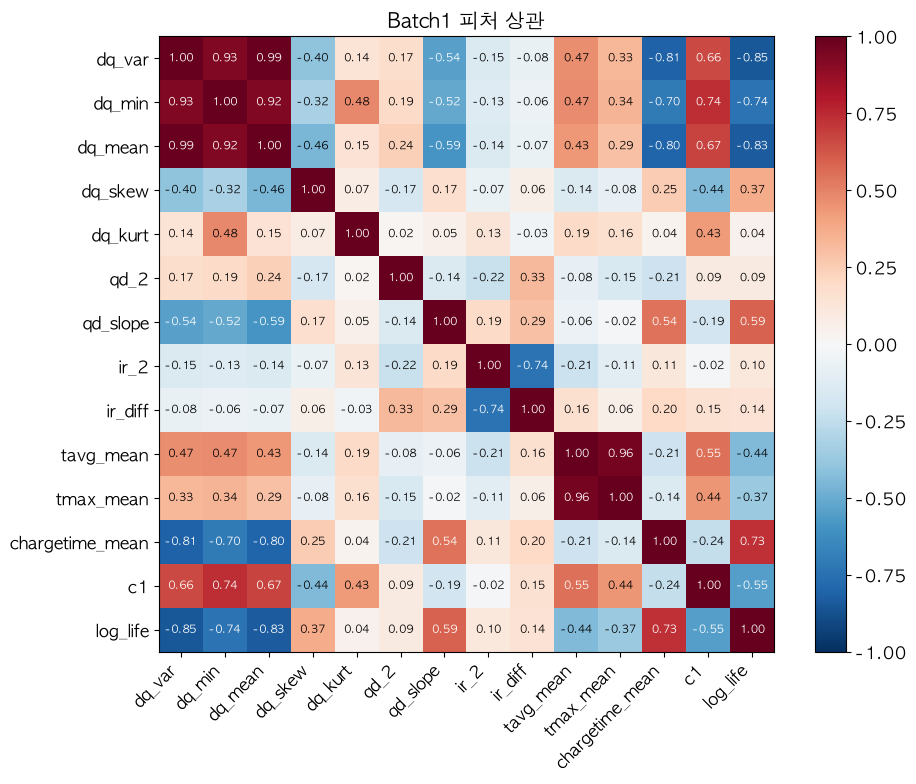

log(cycle_life) 상관 순위
dq_var            -0.846
dq_mean           -0.829
dq_min            -0.740
chargetime_mean    0.727
qd_slope           0.587
c1                -0.552
tavg_mean         -0.439
dq_skew            0.374
tmax_mean         -0.370
ir_diff            0.145
ir_2               0.104
qd_2               0.092
dq_kurt            0.043
Name: log_life, dtype: float64

VIF (10 이상이면 다중공선성 의심)
dq_var             158.2
dq_mean            115.2
dq_min             100.6
tavg_mean           28.8
tmax_mean           23.2
dq_kurt             14.4
ir_diff              8.1
c1                   7.6
chargetime_mean      7.0
ir_2                 6.8
qd_slope             5.3
dq_skew              2.1
qd_2                 1.8
dtype: float64


In [57]:
FEATS = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_2', 'qd_slope',
         'ir_2', 'ir_diff', 'tavg_mean', 'tmax_mean', 'chargetime_mean', 'c1']
f1 = feat[feat.batch == 'batch1']                           # 학습 데이터가 될 Batch 1 기준으로 확인
corr = f1[FEATS + ['log_life']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1); plt.colorbar(im, ax=ax)    # 빨강=양, 파랑=음의 상관
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right'); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')       # 숫자도 표시해 PDF에서 읽기 쉽게
ax.set_title('Batch1 피처 상관'); plt.tight_layout(); plt.show()

print("log(cycle_life) 상관 순위")
print(corr['log_life'].drop('log_life').sort_values(key=abs, ascending=False).round(3))   # 절댓값 기준 정렬 → '가장 강한 관계' 식별

X = f1[FEATS].dropna()                                      # VIF는 결측이 있으면 계산 불가
Xc = sm.add_constant(X)                                     # VIF 계산에는 상수항이 필요
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])], index=X.columns)
print("\nVIF (10 이상이면 다중공선성 의심)"); print(vif.sort_values(ascending=False).round(1))

[발견] Batch1에서 log(cycle_life)와 상관이 가장 큰 feature는 dq_var였다.
단, dq_var·dq_mean·dq_min은 VIF가 100~158로 사실상 같은 정보(ΔQ 곡선의 크기)였고, tavg_mean·tmax_mean도 VIF 23~29로 서로 중복이었다.

[시사점] 이 feature들을 모두 선형 모델에 넣으면 계수가 불안정해지고 해석이 흐려진다.
또한 Batch1 기준 상관 구조가 Batch2/3에서도 유지된다는 보장이 없다.

[전략] 각 중복 그룹에서 대표 하나만 남긴다(dq_var, tavg_mean).
선형 모델은 Elastic Net으로 공선성을 완화하고, 트리 계열 모델과 비교한다.
knee와 전체 사이클 수는 data leakage이므로 입력에서 제외한다.

In [58]:
cols = ['cycle_life', 'dq_var', 'dq_min', 'tavg_mean', 'chargetime_mean', 'qd_slope', 'c1', 'knee']
display(feat.groupby('batch')[cols].agg(['mean', 'std']).round(3))

cycle_life          dq_var        dq_min        tavg_mean         \
             mean      std   mean    std   mean    std      mean    std   
batch                                                                     
batch1    844.717  184.629 -3.921  0.395 -1.468  0.206    32.617  0.918   
batch2    565.744  222.202 -3.593  0.408 -1.311  0.199    32.897  1.146   
batch3   1059.659  313.870 -4.176  0.272 -1.609  0.153    34.174  1.281   

       chargetime_mean        qd_slope          c1            knee           
                  mean    std     mean  std   mean    std     mean      std  
batch                                                                        
batch1          11.012  1.007     -0.0  0.0  5.878  1.203  634.116  164.647  
batch2          10.150  0.064      0.0  0.0  5.031  0.614  433.436  181.940  
batch3          10.182  0.345     -0.0  0.0  5.239  0.540  808.886  242.473

[발견] 수명 평균이 Batch 1 845 / Batch 2 566 / Batch 3 1060으로 크게 달라요. ΔQ 피처(dq_var, dq_min)의 배치 평균은 수명 순서와 같은 방향으로 움직여요. 충전시간은 Batch 2에서 거의 상수(표준편차 0.06분)이고, C-rate 범위는 Batch 1이 가장 넓어요. 온도는 Batch 3이 약 1.6℃ 높은데도 수명이 가장 길어요.

[시사점] ΔQ 기반 신호는 배치를 넘어 일관되게 쓸 수 있지만 평균 이동이 있어요. 충전·온도 피처는 배치마다 범위와 방향이 달라서 Batch 1의 관계가 다른 배치에 전이되지 않을 위험이 커요.

[전략] 핵심 피처는 ΔQ(dq_var)로 하고, 충전·온도 피처는 보조로만 비교해요. 평가는 Batch 2와 Batch 3을 따로 보고하고, 배치 간 오프셋(과대 예측 경향)을 오차 분석에서 확인해요.

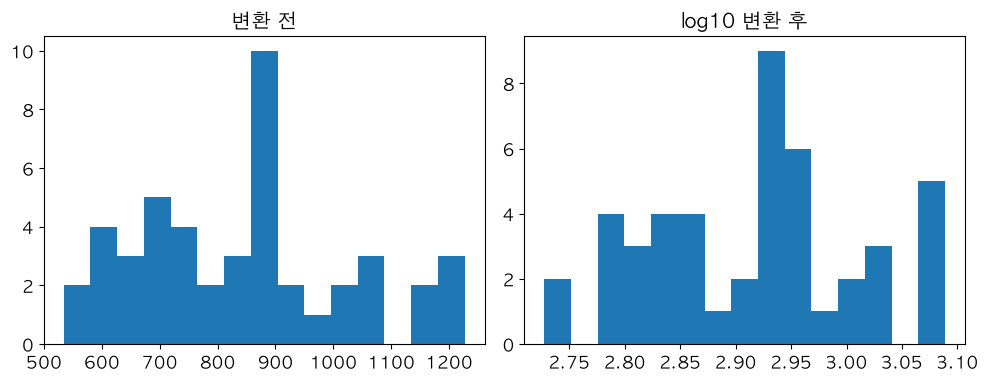

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(feat1['cycle_life'], bins=15);          ax[0].set_title('변환 전')
ax[1].hist(np.log10(feat1['cycle_life']), bins=15); ax[1].set_title('log10 변환 후')
plt.tight_layout()

In [68]:
pd.set_option('display.max_rows', None)

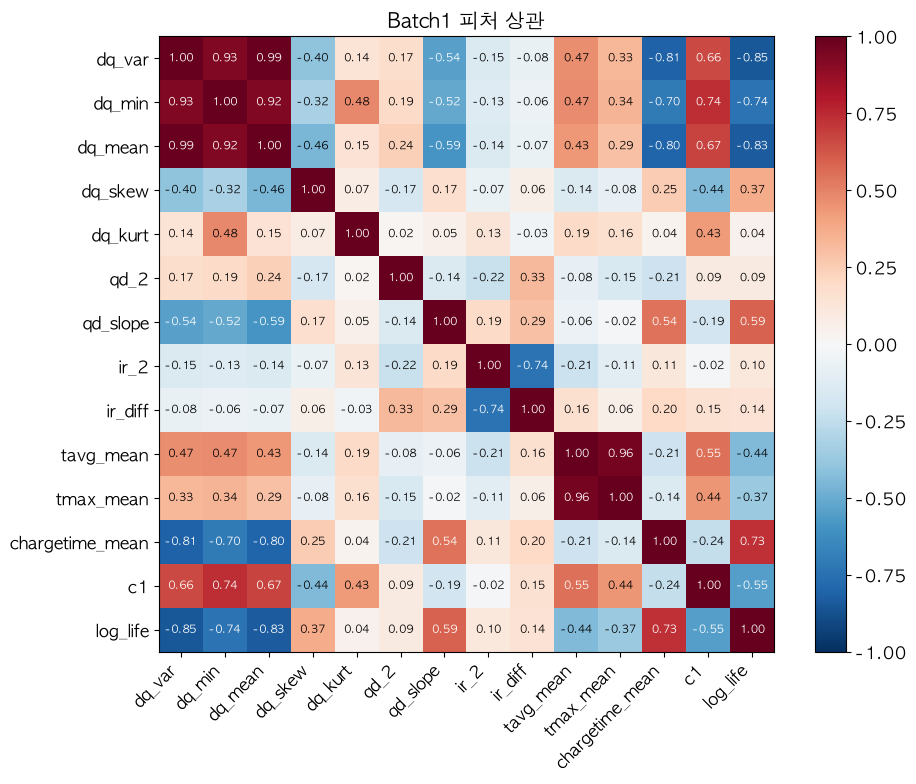

log(cycle_life) 상관 순위
dq_var            -0.846
dq_mean           -0.829
dq_min            -0.740
chargetime_mean    0.727
qd_slope           0.587
c1                -0.552
tavg_mean         -0.439
dq_skew            0.374
tmax_mean         -0.370
ir_diff            0.145
ir_2               0.104
qd_2               0.092
dq_kurt            0.043
Name: log_life, dtype: float64

VIF (10 이상이면 다중공선성 의심)
dq_var             158.2
dq_mean            115.2
dq_min             100.6
tavg_mean           28.8
tmax_mean           23.2
dq_kurt             14.4
ir_diff              8.1
c1                   7.6
chargetime_mean      7.0
ir_2                 6.8
qd_slope             5.3
dq_skew              2.1
qd_2                 1.8


In [69]:


FEATS = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_2', 'qd_slope',
         'ir_2', 'ir_diff', 'tavg_mean', 'tmax_mean', 'chargetime_mean', 'c1']
f1 = feat[feat.batch == 'batch1']                           # 학습 데이터가 될 Batch 1 기준으로 확인
corr = f1[FEATS + ['log_life']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1); plt.colorbar(im, ax=ax)    # 빨강=양, 파랑=음의 상관
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right'); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')       # 숫자도 표시해 PDF에서 읽기 쉽게
ax.set_title('Batch1 피처 상관'); plt.tight_layout(); plt.show()

print("log(cycle_life) 상관 순위")
print(corr['log_life'].drop('log_life').sort_values(key=abs, ascending=False).round(3))   # 절댓값 기준 정렬 → '가장 강한 관계' 식별

X = f1[FEATS].dropna()                                      # VIF는 결측이 있으면 계산 불가
Xc = sm.add_constant(X)                                     # VIF 계산에는 상수항이 필요
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])], index=X.columns)
print("\nVIF (10 이상이면 다중공선성 의심)"); print(vif.sort_values(ascending=False).round(1).to_string())